# Статистический анализ данных сервиса аренды самокатов GoFast.

## Об исследовании

**Заказчик:**  GoFast - сервис краткосрочной аренды самокатов в различных городах России.

**Цель:** Выявить ключевые точки роста, проверить гипотезы менеджеров и сформулировать рекомендации.

**Данные:** Предоставлена информация о пользователях, их поездках и подписках.

**Основаная информация о работе сервиса:**

Чтобы совершать поездки по городу, пользователи сервиса GoFast пользуются мобильным приложением. Сервисом можно пользоваться:
 - без подписки
    - абонентская плата отсутствует;
    - стоимость одной минуты поездки — 8 рублей;
    - стоимость старта (начала поездки) — 50 рублей;
 - с подпиской Ultra
    - абонентская плата — 199 рублей в месяц;
    - стоимость одной минуты поездки — 6 рублей;
    - стоимость старта — бесплатно.

**Описание датасетов:**

Пользователи — `users_go.csv`
- `user_id` - уникальный идентификатор пользователя
- `name` - имя пользователя
- `age` - возраст
- `city` - город
- `subscription_type` - тип подписки (free, ultra)

Поездки — `rides_go.csv`
- `user_id` - уникальный идентификатор пользователя
- `distance` - расстояние, которое пользователь проехал в текущей сессии (в метрах)
- `duration` - продолжительность сессии (в минутах) — время с того момента, как пользователь нажал кнопку «Начать поездку» до момента, как он нажал кнопку «Завершить поездку»
- `date` - дата совершения поездки

Подписки — subscriptions_go.csv
- `subscription_type` - тип подписки
- `minute_price` - стоимость одной минуты поездки по данной подписке
- `start_ride_price` - стоимость начала поездки
- `subscription_fee` - стоимость ежемесячного платежа

<h1>Оглавление<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Об-исследовании" data-toc-modified-id="Об-исследовании-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Об исследовании</a></span></li><li><span><a href="#Начало-работы" data-toc-modified-id="Начало-работы-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Начало работы</a></span></li><li><span><a href="#Предобработка-данных" data-toc-modified-id="Предобработка-данных-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Предобработка данных</a></span><ul class="toc-item"><li><span><a href="#Создание-новых-столбцов" data-toc-modified-id="Создание-новых-столбцов-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Создание новых столбцов</a></span></li><li><span><a href="#Проверка-на-дубликаты" data-toc-modified-id="Проверка-на-дубликаты-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Проверка на дубликаты</a></span></li><li><span><a href="#Проверка-на-пропущенные-значения" data-toc-modified-id="Проверка-на-пропущенные-значения-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>Проверка на пропущенные значения</a></span></li></ul></li><li><span><a href="#Исследовательский-анализ-данных" data-toc-modified-id="Исследовательский-анализ-данных-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Исследовательский анализ данных</a></span><ul class="toc-item"><li><span><a href="#Частота-встречаемости-городов" data-toc-modified-id="Частота-встречаемости-городов-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Частота встречаемости городов</a></span></li><li><span><a href="#Cоотношение-пользователей-с-подпиской-и-без-подписки" data-toc-modified-id="Cоотношение-пользователей-с-подпиской-и-без-подписки-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>Cоотношение пользователей с подпиской и без подписки</a></span></li><li><span><a href="#Возраст-пользователей" data-toc-modified-id="Возраст-пользователей-4.3"><span class="toc-item-num">4.3&nbsp;&nbsp;</span>Возраст пользователей</a></span></li><li><span><a href="#Продолжительность-поездок-и-средняя-скорость" data-toc-modified-id="Продолжительность-поездок-и-средняя-скорость-4.4"><span class="toc-item-num">4.4&nbsp;&nbsp;</span>Продолжительность поездок и средняя скорость</a></span></li><li><span><a href="#Расстояние,-которое-пользователь-преодолел-за-одну-поездку" data-toc-modified-id="Расстояние,-которое-пользователь-преодолел-за-одну-поездку-4.5"><span class="toc-item-num">4.5&nbsp;&nbsp;</span>Расстояние, которое пользователь преодолел за одну поездку</a></span></li></ul></li><li><span><a href="#Объединение-данных" data-toc-modified-id="Объединение-данных-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Объединение данных</a></span><ul class="toc-item"><li><span><a href="#Объединение-данных-о-пользователях,-поездках-и-подписках-в-один-датафрейм" data-toc-modified-id="Объединение-данных-о-пользователях,-поездках-и-подписках-в-один-датафрейм-5.1"><span class="toc-item-num">5.1&nbsp;&nbsp;</span>Объединение данных о пользователях, поездках и подписках в один датафрейм</a></span></li><li><span><a href="#Визуализация-информации-о-расстоянии-и-времени-поездок-для-пользователей-обеих-категорий" data-toc-modified-id="Визуализация-информации-о-расстоянии-и-времени-поездок-для-пользователей-обеих-категорий-5.2"><span class="toc-item-num">5.2&nbsp;&nbsp;</span>Визуализация информации о расстоянии и времени поездок для пользователей обеих категорий</a></span></li></ul></li><li><span><a href="#Подсчёт-выручки" data-toc-modified-id="Подсчёт-выручки-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Подсчёт выручки</a></span></li><li><span><a href="#Проверка-гипотез" data-toc-modified-id="Проверка-гипотез-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Проверка гипотез</a></span><ul class="toc-item"><li><span><a href="#Гипотеза-№1" data-toc-modified-id="Гипотеза-№1-7.1"><span class="toc-item-num">7.1&nbsp;&nbsp;</span>Гипотеза №1</a></span></li><li><span><a href="#Гипотеза-№2" data-toc-modified-id="Гипотеза-№2-7.2"><span class="toc-item-num">7.2&nbsp;&nbsp;</span>Гипотеза №2</a></span></li><li><span><a href="#Гипотеза-№3" data-toc-modified-id="Гипотеза-№3-7.3"><span class="toc-item-num">7.3&nbsp;&nbsp;</span>Гипотеза №3</a></span></li><li><span><a href="#Гипотеза-№4" data-toc-modified-id="Гипотеза-№4-7.4"><span class="toc-item-num">7.4&nbsp;&nbsp;</span>Гипотеза №4</a></span></li></ul></li><li><span><a href="#Распределения" data-toc-modified-id="Распределения-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Распределения</a></span><ul class="toc-item"><li><span><a href="#Рассылка-промокодов" data-toc-modified-id="Рассылка-промокодов-8.1"><span class="toc-item-num">8.1&nbsp;&nbsp;</span>Рассылка промокодов</a></span></li><li><span><a href="#Рассылка-уведомлений" data-toc-modified-id="Рассылка-уведомлений-8.2"><span class="toc-item-num">8.2&nbsp;&nbsp;</span>Рассылка уведомлений</a></span></li></ul></li><li><span><a href="#Вывод" data-toc-modified-id="Вывод-9"><span class="toc-item-num">9&nbsp;&nbsp;</span>Вывод</a></span></li></ul></div>

## Начало работы

In [1]:
# импорт необходимых библиотек
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st
from scipy.stats import binom, norm
from math import sqrt

# при выводе датафрейма будут показываться все колонки
pd.set_option('display.max_columns', None)

# определим формат даты
date_format = '%Y-%m-%d'

# настроим отображение чисел больших порядков в привычном виде
pd.set_option("display.float_format", "{:.2f}".format)

# установим максимальную длину отображаемых строк
pd.set_option('display.max_colwidth', None)

import warnings
warnings.filterwarnings("ignore")

---

In [2]:
try:
    df_users = pd.read_csv('users_go.csv')
    
except:
    df_users = pd.read_csv('https://code.s3.yandex.net/datasets/users_go.csv') 

df_users.head()

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


In [3]:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB


---

In [4]:
try:
    df_rides = pd.read_csv('rides_go.csv', parse_dates=['date'])
    
except:
    df_rides = pd.read_csv('https://code.s3.yandex.net/datasets/rides_go.csv', parse_dates=['date']) 

df_rides.head()

,user_id,distance,duration,date
0,1,4409.92,25.60,2021-01-01
1,1,2617.59,15.82,2021-01-18
2,1,754.16,6.23,2021-04-20
3,1,2694.78,18.51,2021-08-11
4,1,4028.69,26.27,2021-08-28


In [5]:
df_rides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   18068 non-null  int64         
 1   distance  18068 non-null  float64       
 2   duration  18068 non-null  float64       
 3   date      18068 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 564.8 KB


---

In [6]:
try:
    df_subs = pd.read_csv('subscriptions_go.csv')
    
except:
    df_subs = pd.read_csv('https://code.s3.yandex.net/datasets/subscriptions_go.csv') 

df_subs.head()

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


In [7]:
df_subs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 196.0+ bytes


Основная масса информация приходится на датасет о поездках - 18068 записей. Всего есть 2 тарифных плана, их описание соответсвует изложенному в общей информации. Пропусков ни в одной таблице не обнаружено. Типы данных, на первый взгляд, не требуют корректировок.

## Предобработка данных

### Создание новых столбцов

In [10]:
df_rides['month'] = pd.DatetimeIndex(df_rides.date).month

In [11]:
df_rides.head()

,user_id,distance,duration,date,month
0,1,4409.92,25.60,2021-01-01,1
1,1,2617.59,15.82,2021-01-18,1
2,1,754.16,6.23,2021-04-20,4
3,1,2694.78,18.51,2021-08-11,8
4,1,4028.69,26.27,2021-08-28,8


### Проверка на дубликаты

In [12]:
[i.duplicated().sum() for i in [df_users, df_rides, df_subs]]

[31, 0, 0]

В датафрейме с пользователями 31 строка-дубликат. Удалим их с помощью метода `drop_duplicates`. Перезапишем индексы строк, используя метод `reset_index`.

In [13]:
df_users = df_users.drop_duplicates().reset_index(drop=True)

Проверку произведем по идентификатору пользователя. В остальных стобцах дублирующие значения ожидаемы, например, повторяющиеся города, имена и возраст.

In [14]:
df_users.user_id.value_counts()

user_id
1       1
1020    1
1029    1
1028    1
1027    1
       ..
510     1
509     1
508     1
507     1
1534    1
Name: count, Length: 1534, dtype: int64

Дублирующих значений в столбце `user_id` не обнаружено. Поэтому можно судить об уникальности каждой строки в датафрейме.

---

Проверим неявные дубликаты. Для этого выведем список уникальных значений и отсортируем методом `sort`. Создадим функцию.

In [15]:
def sort_unique(df, col):
    print(sorted(df[col].unique()))

Начнем проверку со списка имен, в столбце `name`.

In [16]:
sort_unique(df_users, 'name')

['Агата', 'Аделина', 'Адель', 'Айдар', 'Александр', 'Александра', 'Алексей', 'Алина', 'Алиса', 'Алия', 'Алла', 'Альберт', 'Альбина', 'Алёна', 'Амалия', 'Амина', 'Амир', 'Анастасия', 'Анатолий', 'Ангелина', 'Андрей', 'Анжелика', 'Анна', 'Антон', 'Антонина', 'Ариана', 'Арина', 'Арсен', 'Арсений', 'Артемий', 'Артур', 'Артём', 'Богдан', 'Борис', 'Вадим', 'Валентина', 'Валерий', 'Валерия', 'Варвара', 'Василий', 'Василина', 'Василиса', 'Вера', 'Вероника', 'Виктор', 'Виктория', 'Виолетта', 'Виталий', 'Виталина', 'Влад', 'Влада', 'Владимир', 'Владислав', 'Владислава', 'Всеволод', 'Вячеслав', 'Галина', 'Георгий', 'Герман', 'Глеб', 'Гордей', 'Григорий', 'Давид', 'Дамир', 'Даниил', 'Данил', 'Данила', 'Даниэль', 'Дарина', 'Дарья', 'Демид', 'Денис', 'Диана', 'Дмитрий', 'Ева', 'Евгений', 'Евгения', 'Егор', 'Екатерина', 'Елена', 'Елизавета', 'Елисей', 'Есения', 'Жанна', 'Зарина', 'Захар', 'Злата', 'Иван', 'Игнат', 'Игорь', 'Ильдар', 'Илья', 'Инна', 'Ирина', 'Камилла', 'Карина', 'Каролина', 'Кира', 'К

Все имена прописаны корректно. Тоже самое проделаем для городов.

In [17]:
sort_unique(df_users, 'city')

['Екатеринбург', 'Краснодар', 'Москва', 'Омск', 'Пятигорск', 'Ростов-на-Дону', 'Сочи', 'Тюмень']


Оказывается, сервис проката самокатов GoFast представлен в 8 городах России. Неявных дубликатов нет.

In [18]:
sort_unique(df_users, 'subscription_type')

['free', 'ultra']


В названиии тарифов ошибок нет.

### Проверка на пропущенные значения

При первичном рассмотрении отдельно трех датафреймов `df_users`,`df_rides`,`df_subs` с помощью метода `info` кол-во строк для каждого стобца было одинаковым. Поэтому можно судить об отсутствие пропусков.

## Исследовательский анализ данных

### Частота встречаемости городов

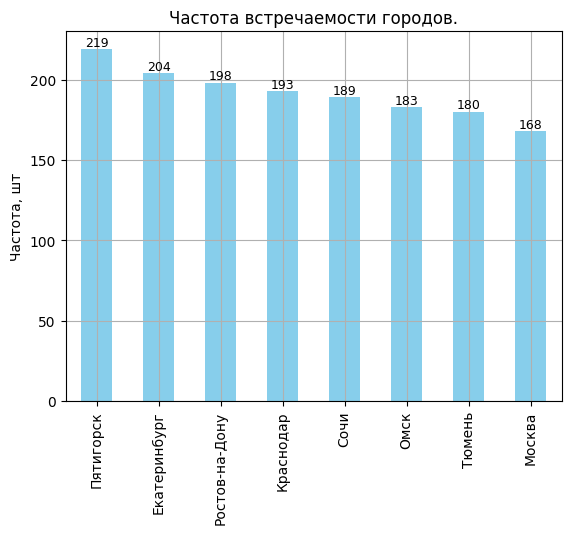

In [19]:
df_users.city.value_counts().plot(kind='bar', color = '#87CEEB', grid = True)
for index, value in enumerate(df_users.city.value_counts()):
    plt.text(index, value+2, str(value), ha='center', fontsize = 9)
plt.title('Частота встречаемости городов.')
plt.xlabel('')
plt.ylabel('Частота, шт')
plt.show()

In [20]:
print(f'Наибольшая встречаемость у Пятигорска - {df_users.city.value_counts().max()}.')
print(f'Наименьшая встречаемость у Москвы - {df_users.city.value_counts().min()}.')

Наибольшая встречаемость у Пятигорска - 219.
Наименьшая встречаемость у Москвы - 168.


### Cоотношение пользователей с подпиской и без подписки

In [21]:
df_users.subscription_type.value_counts()

subscription_type
free     835
ultra    699
Name: count, dtype: int64

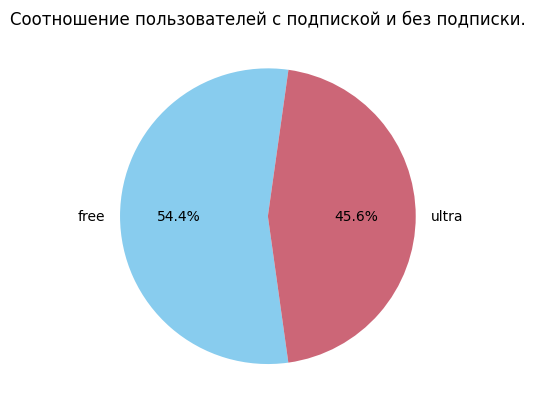

In [22]:
df_users.subscription_type.value_counts().plot(
    kind = 'pie', # круговая диаграмма
    autopct='%.1f%%', # автопроставление процента занимаемой сектором площади, округлено до десятых
    colors=['#88ccee', '#cc6677'],  # подобраны цвета
    title='Cоотношение пользователей с подпиской и без подписки.',
    startangle = 82, # вращение графика
)
plt.ylabel('')
plt.show()

- Пользователей с подпиской - `45,6` процента.
- Пользователей без подписки - `54,4` процента.

### Возраст пользователей

In [23]:
sort_unique(df_users, 'age')

[12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 43]


Видно, что пользователи компании GoFast - молодая часть населения от 12 до 43 лет. Выведем строки с пользователями до 18 лет, используя запрос `query`.

In [24]:
df_users.query('age < 18').sort_values(by='age')

,user_id,name,age,city,subscription_type
664,665,Герман,12,Сочи,ultra
34,35,Руслан,12,Пятигорск,ultra
66,67,Анастасия,12,Ростов-на-Дону,ultra
727,728,Вячеслав,12,Пятигорск,free
553,554,Евгений,13,Тюмень,ultra
...,...,...,...,...,...
175,176,Анна,17,Москва,ultra
715,716,Мелания,17,Москва,free
886,887,Ольга,17,Тюмень,free
466,467,Евгения,17,Екатеринбург,ultra


Изучим за какой промежуток времени сбораны данные и поездках.

In [25]:
try: 
    print(df_rides.date.describe(datetime_is_numeric=True))
    
except: 
    print(df_rides.date.describe()) 

count                            18068
mean     2021-06-30 19:47:21.266327296
min                2021-01-01 00:00:00
25%                2021-04-02 00:00:00
50%                2021-06-30 00:00:00
75%                2021-09-28 00:00:00
max                2021-12-30 00:00:00
Name: date, dtype: object


Возможно, на момент сбора данных - 2021 год, в законодательстве не было статьи об ограничении пользования сервисов по аренде самокатов лицам до 18 лет, ее приняли в 2023 году.

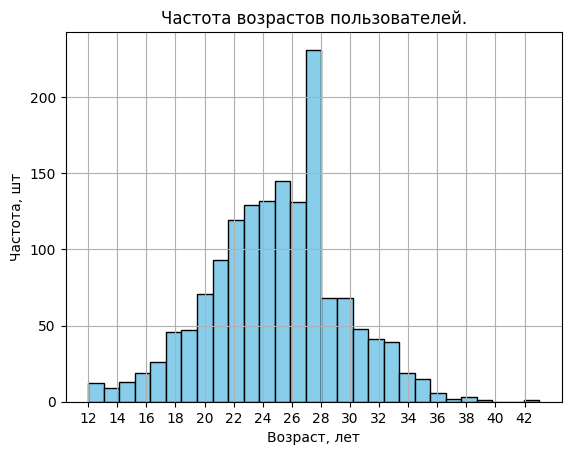

In [26]:
df_users.age.plot(
    kind = 'hist', 
    bins = df_users.age.nunique(),
    xticks = range(12,43,2),
    title = 'Частота возрастов пользователей.',
    ylabel = 'Частота, шт',
    xlabel = 'Возраст, лет',
    color = '#88CEEB',
    edgecolor='black',
    grid = True
)
plt.show()

In [27]:
print(f'Средний возраст пользователей сервиса составляет {int(df_users.age.mean().round())} лет.')
print(f'Минимальный - {df_users.age.min()} лет.')
print(f'Максимальный - {df_users.age.max()} года.')

Средний возраст пользователей сервиса составляет 25 лет.
Минимальный - 12 лет.
Максимальный - 43 года.


### Продолжительность поездок и средняя скорость

Округлим время каждой поездки до целого числа, в большую сторону.

In [28]:
df_rides.loc[:,'duration'] = np.ceil(df_rides['duration']) 

Создадим столбец `speed`, в котором будет значение средней скорости в километрах в час за поездку. Для этого метры переведем в километры, разделив на 1000, а минуты в часы, разделив на 60.

In [29]:
df_rides['speed'] = (df_rides['distance'] / 1000) / (df_rides['duration'] / 60)

In [30]:
df_rides

,user_id,distance,duration,date,month,speed
0,1,4409.92,26.00,2021-01-01,1,10.18
1,1,2617.59,16.00,2021-01-18,1,9.82
2,1,754.16,7.00,2021-04-20,4,6.46
3,1,2694.78,19.00,2021-08-11,8,8.51
4,1,4028.69,27.00,2021-08-28,8,8.95
...,...,...,...,...,...,...
18063,1534,3781.10,20.00,2021-11-04,11,11.34
18064,1534,2840.42,22.00,2021-11-16,11,7.75
18065,1534,3826.19,19.00,2021-11-18,11,12.08
18066,1534,2902.31,17.00,2021-11-27,11,10.24


In [31]:
df_rides['speed'].describe()

count   18068.00
mean       11.84
std        21.96
min         0.00
25%         7.93
50%         9.97
75%        12.51
max       432.66
Name: speed, dtype: float64

Встретилась аномально высокая скорость. Для изучения выбросов построим боксплот.

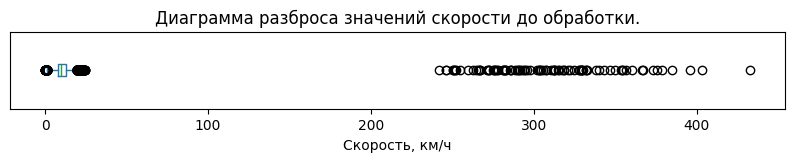

In [32]:
df_rides.speed.plot(
    kind = 'box', 
    vert = False, 
    figsize = (10,1),
    title = 'Диаграмма разброса значений скорости до обработки.',
    xlabel = 'Скорость, км/ч',
    yticks = []
     
)
plt.show()

Какое значение длительности поездки встречается в строках с аномальной скоростью?

In [33]:
df_rides.query('speed > 100').duration.value_counts()

duration
1.00    95
Name: count, dtype: int64

Все 95 строк имеют продолжительность поездки 1 минут. Проверим встречается ли это время в других строках.

In [34]:
df_rides.query('duration == 1').describe()

,user_id,distance,duration,date,month,speed
count,95.00,95.00,95.00,95,95.00,95.00
mean,1092.21,5113.18,1.00,2021-07-01 13:53:41.052631552,6.48,306.79
min,701.00,4030.31,1.00,2021-01-05 00:00:00,1.00,241.82
25%,901.00,4611.51,1.00,2021-03-16 00:00:00,3.00,276.69
50%,1069.00,5052.77,1.00,2021-06-18 00:00:00,6.00,303.17
75%,1310.50,5488.46,1.00,2021-10-18 12:00:00,10.00,329.31
max,1524.00,7211.01,1.00,2021-12-27 00:00:00,12.00,432.66
std,244.03,658.25,0.00,NaN,3.71,39.50


Нет, не встречается в других строках.

In [35]:
print(f'Соотношение нестандартных значений по отношению к общему числу записей: {round((df_rides.duration == 1).sum() / df_rides.duration.count(), 4)*100}%')

Соотношение нестандартных значений по отношению к общему числу записей: 0.53%


Удаление 0.53% выборки не повлияет на результат. 

In [36]:
df_rides = df_rides[df_rides.duration != 1]

Построим диграмму разброса для столбца `speed` после обработки данных.

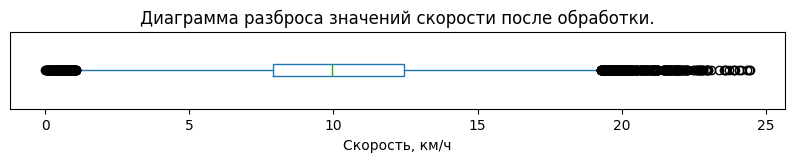

In [37]:
df_rides.speed.plot(
    kind = 'box', 
    vert = False, 
    figsize = (10,1),
    title = 'Диаграмма разброса значений скорости после обработки.',
    xlabel = 'Скорость, км/ч',
    yticks = []
     
)
plt.show()

Разброс значений срендней скорости - от 0 до 25 км/ч. Именно такой диапазон встречается у самокатов.

Повторно изучим обработанный датафрейм с поездками.

In [38]:
df_rides.describe()

,user_id,distance,duration,date,month,speed
count,17973.00,17973.00,17973.00,17973,17973.00,17973.00
mean,841.55,3059.86,18.39,2021-06-30 19:41:36.745117696,6.49,10.28
min,1.00,0.86,3.00,2021-01-01 00:00:00,1.00,0.00
25%,484.00,2538.84,14.00,2021-04-02 00:00:00,4.00,7.91
50%,887.00,3129.03,18.00,2021-06-30 00:00:00,6.00,9.95
75%,1213.00,3762.64,22.00,2021-09-28 00:00:00,9.00,12.46
max,1534.00,7066.00,41.00,2021-12-30 00:00:00,12.00,24.44
std,435.14,1108.81,5.98,NaN,3.44,3.80


Построим гистограмму длительность поездок.

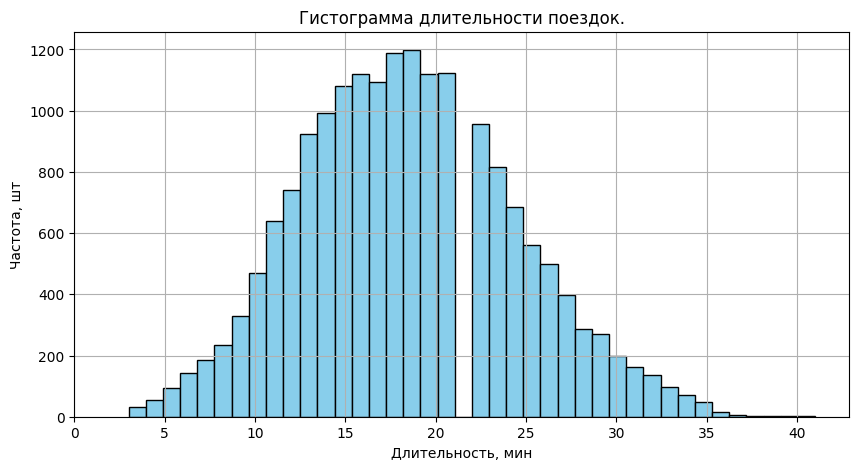

In [39]:
df_rides.duration.plot(
    kind = 'hist', 
    bins = 40,
    xticks = range(0, 41, 5 ),
    title = 'Гистограмма длительности поездок.',
    ylabel = 'Частота, шт',
    xlabel = 'Длительность, мин',
    color = '#88CEEB',
    edgecolor='black',
    grid = True,
    figsize = (10,5)
)
plt.show()

In [40]:
print(f'Средняя длительность поездки составляет {int(df_rides.duration.mean().round())} минут.')

Средняя длительность поездки составляет 18 минут.


### Расстояние, которое пользователь преодолел за одну поездку

Построим гистограмму дистанции поездок. Определим диапазон значений оси X, для этого найдем минимальное и максимальное значения.

In [41]:
df_rides.distance.describe()[['min','max']]

min      0.86
max   7066.00
Name: distance, dtype: float64

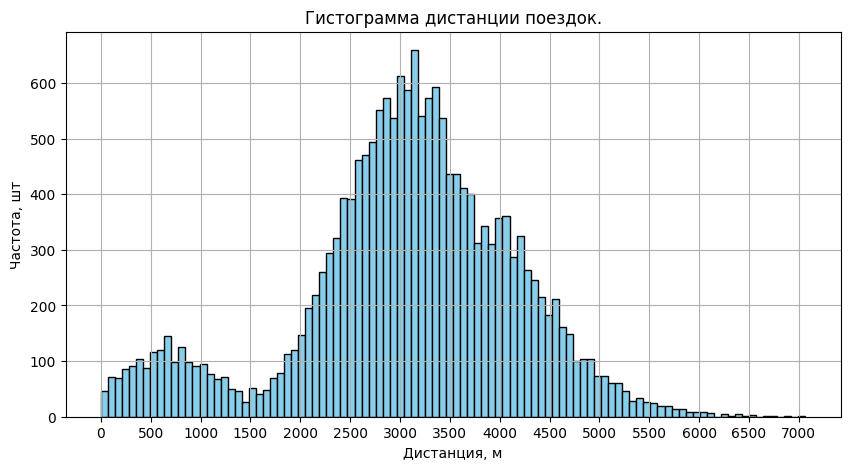

In [42]:
df_rides.distance.plot(
    kind = 'hist', 
    bins = 100,
    xticks = range(0, 7001, 500),
    title = 'Гистограмма дистанции поездок.',
    ylabel = 'Частота, шт',
    xlabel = 'Дистанция, м',
    color = '#88CEEB',
    edgecolor='black',
    grid = True,
    figsize = (10,5)
)
plt.show()

Наиболее популярная дистанция - `2000-4500` метров с модой `~3200` при параметре `bins=100`. Хотя наблюдается невысокий пик в районе 600 метров, что говорит о спросе на короткие поездки тоже.

In [43]:
print(f'Медианная дистанция поездок составляет {int(df_rides.distance.median().round())} метров.')
print(f'Средняя дистанция поездок составляет {int(df_rides.distance.mean().round())} метров.')

Медианная дистанция поездок составляет 3129 метров.
Средняя дистанция поездок составляет 3060 метров.


## Объединение данных

### Объединение данных о пользователях, поездках и подписках в один датафрейм

Проверим кол-во строк в датафреймах.

In [44]:
dataframes = {"df_rides": df_rides, "df_users": df_users, "df_subs": df_subs}

for name, df in dataframes.items():
    print(f"Кол-во строк в {name} - {len(df)}")

Кол-во строк в df_rides - 17973
Кол-во строк в df_users - 1534
Кол-во строк в df_subs - 2


Создадим новый датафрейм `full_data`, объединив `df_users` c `df_rides` по столбцу `user_id` методом `inner`, также добавим датафрейм `df_subs` по столбцу `subscription_type`.

In [45]:
full_data = df_rides.merge(df_users, on = 'user_id').merge(df_subs, on = 'subscription_type')

In [46]:
full_data

,user_id,distance,duration,date,month,speed,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee
0,1,4409.92,26.00,2021-01-01,1,10.18,Кира,22,Тюмень,ultra,6,0,199
1,1,2617.59,16.00,2021-01-18,1,9.82,Кира,22,Тюмень,ultra,6,0,199
2,1,754.16,7.00,2021-04-20,4,6.46,Кира,22,Тюмень,ultra,6,0,199
3,1,2694.78,19.00,2021-08-11,8,8.51,Кира,22,Тюмень,ultra,6,0,199
4,1,4028.69,27.00,2021-08-28,8,8.95,Кира,22,Тюмень,ultra,6,0,199
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17968,1534,3781.10,20.00,2021-11-04,11,11.34,Альберт,25,Краснодар,free,8,50,0
17969,1534,2840.42,22.00,2021-11-16,11,7.75,Альберт,25,Краснодар,free,8,50,0
17970,1534,3826.19,19.00,2021-11-18,11,12.08,Альберт,25,Краснодар,free,8,50,0
17971,1534,2902.31,17.00,2021-11-27,11,10.24,Альберт,25,Краснодар,free,8,50,0


После объединения кол-во строк должно остаться равным большему датафрейму - `17973`. Проверим не пояились ли пропуски.

In [47]:
full_data.isna().sum()

user_id              0
distance             0
duration             0
date                 0
month                0
speed                0
name                 0
age                  0
city                 0
subscription_type    0
minute_price         0
start_ride_price     0
subscription_fee     0
dtype: int64

Ни в одном столбце пропусков нет, объединение выполненно корректно.

### Визуализация информации о расстоянии и времени поездок для пользователей обеих категорий

Создадим 2 датафрейма. В первый попадут пользователи без подписки, во второй - с подпиской.

In [48]:
free_type = full_data[full_data.subscription_type == 'free']
ultra_type = full_data[full_data.subscription_type == 'ultra']

---

**Длительность поездок.**

Построим гистограммы для каждой категории в одном поле, для наглядного сравнения.

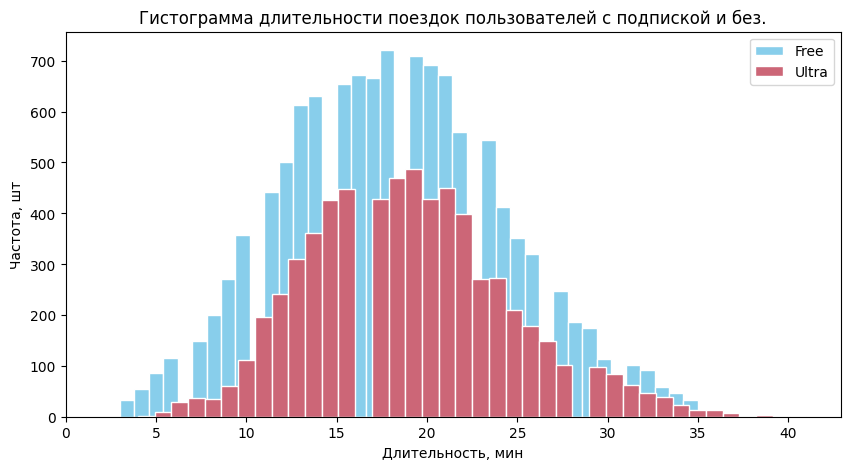

In [49]:
free_type.duration.plot(
    kind = 'hist', 
    bins = 40,
    color = '#88CEEB',
    edgecolor='white',
    label = 'Free'
)
ultra_type.duration.plot(
    kind = 'hist', 
    bins = 40,
    color = '#CC6677',
    edgecolor='white',
    label = 'Ultra',
    xticks = range(0, 41, 5 ),
    ylabel = 'Частота, шт',
    xlabel = 'Длительность, мин',
    figsize = (10,5),
    title = 'Гистограмма длительности поездок пользователей с подпиской и без.'
)
plt.legend()
plt.show()

In [50]:
print('Средняя длительность поездок пользователей без подписки составляет',free_type.duration.mean(),'минут.')
print('Средняя длительность поездок пользователей с подпиской составляет',ultra_type.duration.mean(),'минут.')

Средняя длительность поездок пользователей без подписки составляет 18.030855050989278 минут.
Средняя длительность поездок пользователей с подпиской составляет 19.037692307692307 минут.


---

**Дистанция поездок.**

Построим такой же график только для дистанции.

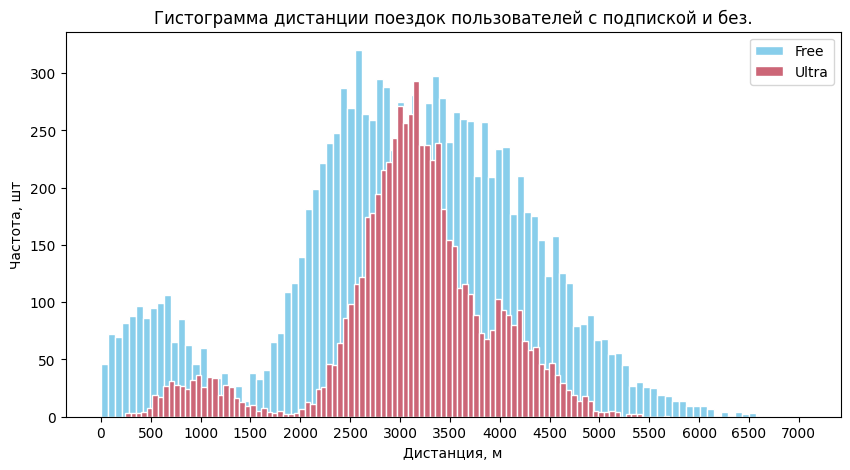

In [51]:
free_type.distance.plot(
    kind = 'hist', 
    bins = 100,
    color = '#88CEEB',
    edgecolor='white',
    label = 'Free'
)
ultra_type.distance.plot(
    kind = 'hist', 
    bins = 100,
    xticks = range(0, 7001, 500),
    color = '#CC6677',
    edgecolor='white',
    figsize = (10,5),
    label = 'Ultra',
    title = 'Гистограмма дистанции поездок пользователей с подпиской и без.',
    ylabel = 'Частота, шт',
    xlabel = 'Дистанция, м'
)
plt.legend()
plt.show()

In [52]:
print('Средняя дистанция поездок пользователей без подписки составляет',free_type.distance.mean(),'метров.')
print('Средняя дистанция поездок пользователей с подпиской составляет',ultra_type.distance.mean(),'метров.')

Средняя дистанция поездок пользователей без подписки составляет 3028.3742391936416 метров.
Средняя дистанция поездок пользователей с подпиской составляет 3115.4453880370247 метров.


<div class="alert alert-info"  
<b>Добавил сводную таблицу

Проверим, как медиана различается по городам для поездок с дистанцией до 1500 метров у пользователей с подпиской и без.

In [53]:
full_data.query('distance < 1500').pivot_table(
    index = 'city', 
    columns = 'subscription_type', 
    values = 'distance', 
    aggfunc = 'median')

subscription_type,free,ultra
city,,
Екатеринбург,597.39,926.06
Краснодар,519.56,1081.56
Москва,549.05,885.65
Омск,540.14,923.28
Пятигорск,611.91,949.96
Ростов-на-Дону,628.35,959.49
Сочи,593.00,959.47
Тюмень,634.94,1020.77


**Длительность:**

Распределение длительности поездок близко к нормальному. Размах варьирования у обоих категорий схож. Хоть среднии и отличаются на единицу (ultra - 19 мин, free - 18 мин), но на графике это не сильно прослеживается. Синяя область выше - закономерно, ведь пользователей без подписки, а значит и записей поездок больше.

**Дистанция:**

Распределение дистанции поездок выглядит иным образом. График имеет несколько пиков, для обоих категорий:  до 1500 метров и основной 2000-4500 метров. Форма основного пика для пользоватлей без подписки более широкая, чем форма основого пика для пользователей с подпиской. Возможно, люди приобретают подписку для постоянных поездок по определенным маршрутам, что делает разброс меньше. 

Заметен сдвиг красной области -  пользователей с подпиской, вправо. Это доказывает увеличенное на 87 пунктов среднее (free - 3028, ultra - 3115). У пользователей без подписки медиана для коротких поездок (до 1500 метров) лежит в диапозоне 520-635 метров, для пользователей с подпиской - 885-1080 метров. При том, что старт для пользователей с подпиской - бесплатный, коротких поездок у них меньше. 

Почти отсутсвие поездок средней дальности (1500-2000 метров) тяжело объясняется имеющимися данными, возможно, произошла утрата данных.

## Подсчёт выручки

Создадим датафрейм с агрегированными данными о поездках на основе датафрейма с объединёнными данными `full_data`. Найдем суммарное расстояние, количество поездок и суммарное время для каждого пользователя за каждый месяц. Для этого построим сводную таблицу, обозначенные индексы переведем в столбцы методом `reset_index`.

In [54]:
df_agg = full_data.pivot_table(
    index = ['user_id' , 'month'], 
    values = ['duration', 'distance'],
    aggfunc =  {
        'distance' : ['sum', 'count'],
        'duration' : 'sum'
    }
).reset_index()

df_agg

user_id month distance          duration
                       count      sum      sum
0           1     1        2  7027.51    42.00
1           1     4        1   754.16     7.00
2           1     8        2  6723.47    46.00
3           1    10        2  5809.91    32.00
4           1    11        3  7003.50    56.00
...       ...   ...      ...      ...      ...
11295    1534     6        2  3409.47    26.00
11296    1534     8        2  7622.45    48.00
11297    1534     9        1  4928.17    23.00
11298    1534    11        4 13350.02    78.00
11299    1534    12        1  2371.71    16.00

[11300 rows x 5 columns]

Переименуем двухэтажные заголовки столбцов.

In [55]:
df_agg.columns = ['user_id', 'month', 'rides_count', 'sum_dist', 'sum_dur']
df_agg

,user_id,month,rides_count,sum_dist,sum_dur
0,1,1,2,7027.51,42.00
1,1,4,1,754.16,7.00
2,1,8,2,6723.47,46.00
3,1,10,2,5809.91,32.00
4,1,11,3,7003.50,56.00
...,...,...,...,...,...
11295,1534,6,2,3409.47,26.00
11296,1534,8,2,7622.45,48.00
11297,1534,9,1,4928.17,23.00
11298,1534,11,4,13350.02,78.00


Добавим информацию о пользователях и их тарифных планов. Для этого, как в пункте 5.1, объединим датафреймы методом `merge`.

In [56]:
df_agg = df_agg.merge(df_users, on='user_id').merge(df_subs, on='subscription_type')
df_agg

,user_id,month,rides_count,sum_dist,sum_dur,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee
0,1,1,2,7027.51,42.00,Кира,22,Тюмень,ultra,6,0,199
1,1,4,1,754.16,7.00,Кира,22,Тюмень,ultra,6,0,199
2,1,8,2,6723.47,46.00,Кира,22,Тюмень,ultra,6,0,199
3,1,10,2,5809.91,32.00,Кира,22,Тюмень,ultra,6,0,199
4,1,11,3,7003.50,56.00,Кира,22,Тюмень,ultra,6,0,199
...,...,...,...,...,...,...,...,...,...,...,...,...
11295,1534,6,2,3409.47,26.00,Альберт,25,Краснодар,free,8,50,0
11296,1534,8,2,7622.45,48.00,Альберт,25,Краснодар,free,8,50,0
11297,1534,9,1,4928.17,23.00,Альберт,25,Краснодар,free,8,50,0
11298,1534,11,4,13350.02,78.00,Альберт,25,Краснодар,free,8,50,0


В полученный датафрейм добавим столбец с помесячной выручкой, которую принес каждый пользователь. Переведем число в целочисленный формат. 

Помесячная выручка считается по формуле: `стоимость старта поездки ×  количество поездок + стоимость одной минуты поездки × общая продолжительность всех поездок в минутах + стоимость подписки`. 

In [57]:
df_agg['month_revenue'] = (df_agg.subscription_fee + df_agg.start_ride_price * df_agg.rides_count + df_agg.minute_price * df_agg.sum_dur).astype('int')
df_agg

,user_id,month,rides_count,sum_dist,sum_dur,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee,month_revenue
0,1,1,2,7027.51,42.00,Кира,22,Тюмень,ultra,6,0,199,451
1,1,4,1,754.16,7.00,Кира,22,Тюмень,ultra,6,0,199,241
2,1,8,2,6723.47,46.00,Кира,22,Тюмень,ultra,6,0,199,475
3,1,10,2,5809.91,32.00,Кира,22,Тюмень,ultra,6,0,199,391
4,1,11,3,7003.50,56.00,Кира,22,Тюмень,ultra,6,0,199,535
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11295,1534,6,2,3409.47,26.00,Альберт,25,Краснодар,free,8,50,0,308
11296,1534,8,2,7622.45,48.00,Альберт,25,Краснодар,free,8,50,0,484
11297,1534,9,1,4928.17,23.00,Альберт,25,Краснодар,free,8,50,0,234
11298,1534,11,4,13350.02,78.00,Альберт,25,Краснодар,free,8,50,0,824


Интересно проверить, насколько разная средняя годовая выручка на 1 пользователя в каждом городе.

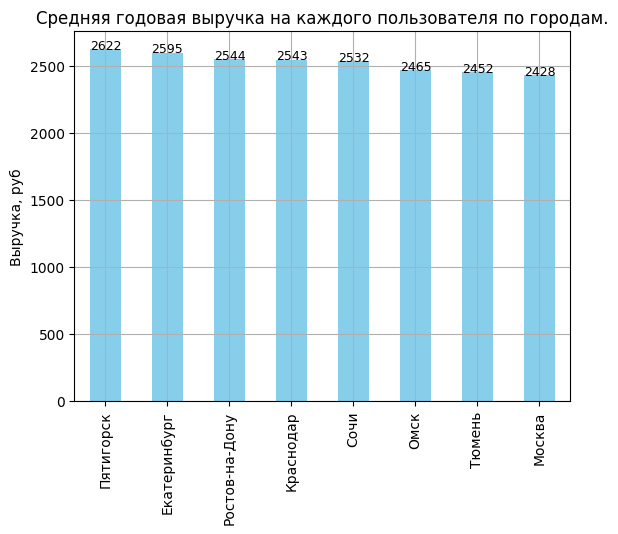

In [58]:
a = (df_agg.groupby('city')['month_revenue'].sum() / df_users.city.value_counts()).sort_values(ascending=False)
a.plot.bar(color = '#87CEEB', grid = True)
df_users.city.value_counts().plot(kind='bar', color = '#87CEEB', grid = True)
for index, value in enumerate(a):
    value = int(value)
    plt.text(index, value+2, str(value), ha='center', fontsize = 9)
plt.title('Средняя годовая выручка на каждого пользователя по городам.')
plt.xlabel('')
plt.ylabel('Выручка, руб')
plt.show()

Видим, что выручка отличается не сильно и находится в диапазоне 2430-2620 руб. Как и в частоте встречаемости городов, Пятигорск на первом месте, Москва - на последнем.

## Проверка гипотез

Продакт-менеджеры сервиса хотят увеличить количество пользователей с подпиской. Для этого они будут проводить различные акции, но сначала нужно выяснить несколько важных моментов.

### Гипотеза №1

Важно понять, тратят ли пользователи с подпиской больше времени на поездки? Если да, то пользователи с подпиской могут быть «выгоднее» для компании. Проверьте гипотезу. Используйте исходные данные о продолжительности каждой сессии — отдельно для подписчиков и тех, у кого нет подписки.


Для проверки данной гипотезы используем t-тест для двух независимых выборок, метод - `ttest_ind`. В качестве параметров передадим: 
- первую выборку - продолжительность поездок пользователей с подпиской - `ultra_type.duration`; 
- вторую выборку - продолжительность поездок пользователей без подписки - `free_type.duration`;
- тип альтернативной гипотезы - `alterntive = 'greater'`, тк мы проверяем альтернативную правостороннюю гипотезу о том, истинное среднее первой выборки, больше истинного среднего второй выборки;
- согласно, совместной гистограмме распредления продолжительности поездок у пользователей двух категорий [Пункт 5.2, длительность поездок.](#Визуализация-информации-о-расстоянии-и-времени-поездок-для-пользователей-обеих-категорий), разброс двух выборок от 0 до 40 мин. Это означает, что дисперсии будут примерно равны. Тогда аргумент `equal_var` оставим без изменения, по умолчанию он равен `True`.


Уровень значимости - `alpha = 0.05`.

Гипотезы исследования:
- H0 - среднии продолжительности сессий для двух категорий пользователей равны;
- Н1 - пользователи с подпиской (первая выборка) тратят больше времени на поездки, чем пользователи без подписки (вторая выборка).

In [59]:
alpha = 0.05

ttest_1 = st.ttest_ind(
    ultra_type.duration,
    free_type.duration, 
    alternative = 'greater'
)

print('Средняя первой выборки (ultra_type):',ultra_type.duration.mean()) 
print('Средняя второй выборки (free_type):',free_type.duration.mean())
print('p-value:', ttest_1.pvalue)

if ttest_1.pvalue < alpha:
    print('Отвергаем нулевую гипотезу, принимаем альтернативную.')
else:
    print('Принимаем нулевую гипотезу, отвергаем альтернативную.')

Средняя первой выборки (ultra_type): 19.037692307692307
Средняя второй выборки (free_type): 18.030855050989278
p-value: 8.577910347796266e-28
Отвергаем нулевую гипотезу, принимаем альтернативную.


**Вывод: пользователи с подпиской тратят больше времени на поездки, чем пользователи без подписки**.

### Гипотеза №2

Расстояние одной поездки в 3130 метров — оптимальное с точки зрения износа самоката. Можно ли сказать, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров? Проверьте гипотезу и сделайте выводы.

Для проверки данной гипотезы используем t-тест для одной выборки, метод - `ttest_1samp`. 

В качестве параметров передадим: 
- выборку - дистанции поездок пользователей с подпиской `ultra_type.distance`; 
- предполагаемое среднее `value`;
- тип альтернативной гипотезы -  `alterntive = 'greater'`, тк мы проверяем правостороннюю гипотезу о том, что истинное среднее превышает значение `value`.

Уровень значимости - `alpha = 0.05`.

Гипотезы исследования:
- H0 - среднее расстояние поездки для пользователей с подпиской не превышает 3130 метров;
- Н1 - среднее расстояние поездки для пользователей с подпиской превышает 3130 метров.

In [60]:
value = 3130

ttest_2 = st.ttest_1samp(
    ultra_type.distance,
    value, 
    alternative = 'greater'
)

print('Среднее выборки:', ultra_type.distance.mean())
print('p-value:', ttest_2.pvalue)

if ttest_2.pvalue < alpha:
    print('Отвергаем нулевую гипотезу, принимаем альтернативную.')
else:
    print('Принимаем нулевую гипотезу, отвергаем альтернативную.')

Среднее выборки: 3115.4453880370247
p-value: 0.9195368847849785
Принимаем нулевую гипотезу, отвергаем альтернативную.


**Вывод: среднее расстояние, которое проезжает пользователь с подпиской, не превышает 3130 метров.**

### Гипотеза №3

Проверьте гипотезу о том, будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки. Сделайте вывод.

Для проверки данной гипотезы используем t-тест для двух независимых выборок, метод - `ttest_ind`. В качестве параметров передадим: 
- первую выборку - помесячная выручка от пользователей с подпиской; 
- вторую выборку - помесячная выручка от пользователей без подписки;
- тип альтернативной гипотезы - `alterntive = 'greater'`, тк мы проверяем альтернативную правостороннюю гипотезу о том, что истинное среднее первой выборки, больше истинного среднего второй выборки;
- `equal_var = False` - тк дисперсии двух групп могут отличаться.


Уровень значимости - `alpha = 0.05`.

Гипотезы исследования:
- H0 - средние помесяные выручки пользователей двух категорий равны;
- Н1 - средняя помесячная выручка от пользователей с подпиской по месяцам выше, чем средняя выручка от пользователей без подписки.

In [61]:
ttest_3 = st.ttest_ind(
    df_agg[df_agg.subscription_type == 'ultra']['month_revenue'],
    df_agg[df_agg.subscription_type == 'free']['month_revenue'], 
    alternative = 'greater'
)

print('Средняя первой выборки (ultra):', df_agg[df_agg.subscription_type == 'ultra']['month_revenue'].mean()) 
print('Средняя второй выборки (free):', df_agg[df_agg.subscription_type == 'free']['month_revenue'].mean())
print('p-value:', ttest_3.pvalue)

if ttest_3.pvalue < alpha:
    print('Отвергаем нулевую гипотезу, принимаем альтернативную.')
else:
    print('Принимаем нулевую гипотезу, отвергаем альтернативную.')

Средняя первой выборки (ultra): 362.7921906022502
Средняя второй выборки (free): 329.3326437121324
p-value: 2.0314113674863288e-30
Отвергаем нулевую гипотезу, принимаем альтернативную.


**Вывод: средняя выручка от пользователей с подпиской выше, чем от пользователей без подписки.**

### Гипотеза №4

Представьте такую ситуацию: техническая команда сервиса обновила сервера, с которыми взаимодействует мобильное приложение. Она надеется, что из-за этого количество обращений в техподдержку значимо снизилось. Некоторый файл содержит для каждого пользователя данные о количестве обращений до обновления и после него. Какой тест вам понадобился бы для проверки этой гипотезы?

**Ответ:**

Для проверки этой гипотезы нужно применить метод сравнивающий две зависимые выборки, метод - `ttest_rel`. Сравнивается, условно, поведение пользователей до и после события (обновления). Кол-во записей не должно различаться в двух выборках, тк каждое значение из первой выборки сравнивается с таким же по порядку значением из второй. Тк команда хочет выяснить меньше ли стало кол-во обращений, проверяется левосторонняя альтернативная гипотеза, поэтому в метод передается аргумент `alternative = 'less'`.

## Распределения

### Рассылка промокодов

Отделу маркетинга GoFast поставили задачу: нужно провести акцию с раздачей промокодов на один бесплатный месяц подписки, в рамках которой как минимум 100 существующих клиентов должны продлить эту подписку. То есть по завершении периода действия подписки пользователь может либо отказаться от неё, либо продлить, совершив соответствующий платёж. 

Эта акция уже проводилась ранее и по итогу выяснилось, что после бесплатного пробного периода подписку продлевают 10 % пользователей. Выясните, какое минимальное количество промокодов нужно разослать, чтобы вероятность не выполнить план была примерно 5 %. Подберите параметры распределения, описывающего эту ситуацию, постройте график распределения и сформулируйте ответ на вопрос о количестве промокодов.

**Решение:**
Аппроксимируем биномиальное распредление нормальным. Необходимо эмпирически подобрать значение n, чтобы вероятность выполнения плана составляла 95 процентов. Те площадь левее 100 на нормальном распределении меньше или равна 0.05.

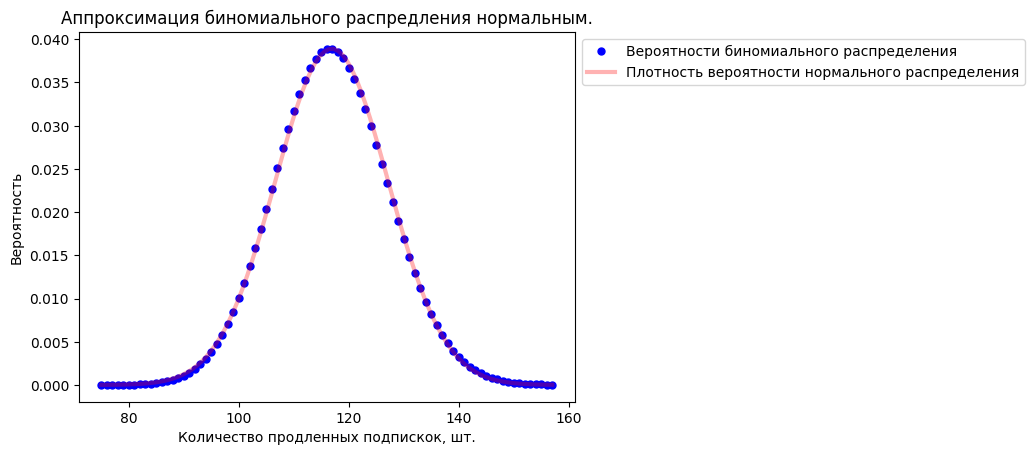

Условие аппроксимации выполняется.
Вероятность выполнения плана: 0.9502851068730583


In [62]:
n = 1169  # требуется подобрать значение
p = 0.1 # вероятность продления подписки

# Создадим биномиальное распределение
binom_distr = pd.Series(
    [binom.pmf(k, n, p) for k in range(0, n + 1)],
    index=range(0, n + 1)
)
    
mu = n * p # математическое ожидание, по данным из биномиального распредления
sigma = sqrt(n * p * (1-p)) # стандартное отклонение, по данным из биномиального распредления

left = int(mu - 4 * sigma) # левая граница биномиального распредления, откуда пойдет аппроксимации
right = int(mu + 4 * sigma) # правая граница биномиального распредления, где закончится аппроксимация

# зададим набор значений биномиальной величины на выбранном промежутке:
# все неотрицательные целые числа от left до right
# зададим область для аппроксимации имеющегося биномиального распредления
binom_distr = binom_distr.loc[list(range(max(0, left), right + 1))]



# зададим функцию, которая выдаёт <num> чисел, равномерно распределённых от <start> до <stop>
def linspace (start, stop, num):
    step = (stop - start) / (num - 1)
    result = []
    for i in range (num):
        result.append(start + step * i)
    return result

x = linspace(max(0,left), right, 100) # получим список из 100 чисел от left до right для нормального распределния
# зададим нормальное распределение из индексов - ось x,
# значений плотности вероятности нормального распредления (метод pdf) - ось y
norm_distr = pd.Series(index = x, data = norm.pdf(x, mu, sigma)) 


ax = plt.subplot() # строим график
ax.plot(binom_distr, 'bo', ms=5, label='Вероятности биномиального распределения') # биномиальное распределения, синими точками
ax.plot(norm_distr, 'r-', lw=3, alpha=0.3, label='Плотность вероятности нормального распределения') # нормальное распределения, красной полосой

plt.title('Аппроксимация биномиального распредления нормальным.')
plt.ylabel('Вероятность')
plt.xlabel('Количество продленных подпискок, шт.')
plt.legend(bbox_to_anchor=(1, 1)) # сместим легенду вправо
plt.show()

# Проверка, выполняется ли наше условие аппроксимации:
# лежит ли mu ± 3 sigma в промежутке от 0 до n:
if ((mu - 3 * sigma) >= 0) and ((mu + 3 * sigma) <= n):
    print('Условие аппроксимации выполняется.')
else:
    print('Условие аппроксимации не выполняется.')
    
print('Вероятность выполнения плана:', 1 - st.norm(mu, sigma).cdf(100))

**Вывод: для того, чтобы с вероятностью в 95% выполнить план по не менее 100 продленных подписок, требуется разослать 1168 промокодов.**

### Рассылка уведомлений

Отдел маркетинга рассылает клиентам push-уведомления в мобильном приложении. Клиенты могут открыть его или не открывать. Известно, что уведомления открывают около 40 % получивших клиентов. Отдел планирует разослать 1 млн уведомлений. С помощью аппроксимации постройте примерный график распределения и оцените вероятность того, что уведомление откроют не более 399,5 тыс. пользователей.

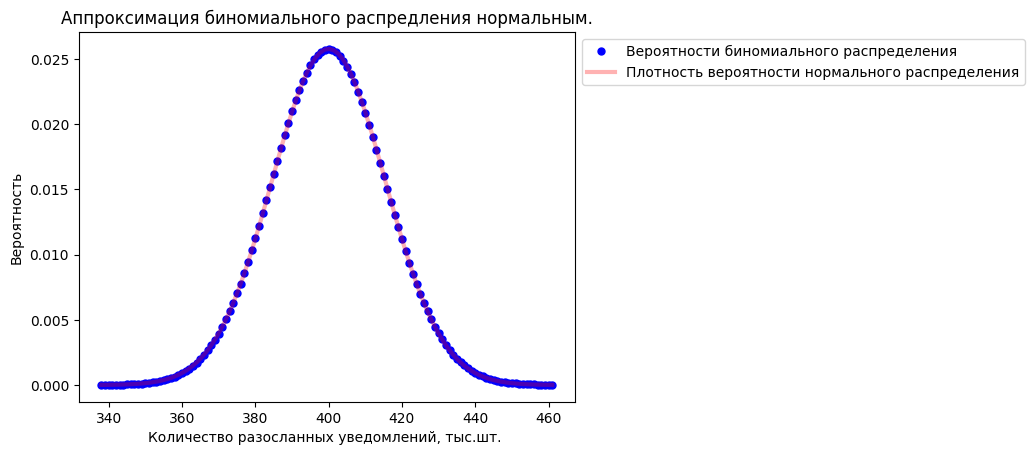

Условие аппроксимации выполняется.
Вероятность того, что письмо откроют не более 399,5 тыс. пользователей: 0.48712642829977193


In [63]:
n = 1000  # единица измерения - тысяча
p = 0.4 # вероятность продления подписки

# Создадим биномиальное распределение
binom_distr = pd.Series(
    [binom.pmf(k, n, p) for k in range(0, n + 1)],
    index=range(0, n + 1)
)
    
mu = n * p # математическое ожидание, по данным из биномиального распредления
sigma = sqrt(n * p * (1-p)) # стандартное отклонение, по данным из биномиального распредления

left = int(mu - 4 * sigma) # левая граница биномиального распредления, откуда пойдет аппроксимации
right = int(mu + 4 * sigma) # правая граница биномиального распредления, где закончится аппроксимация

# зададим набор значений биномиальной величины на выбранном промежутке:
# все неотрицательные целые числа от left до right
# зададим область для аппроксимации имеющегося биномиального распредления
binom_distr = binom_distr.loc[list(range(max(0, left), right + 1))]



# зададим функцию, которая выдаёт <num> чисел, равномерно распределённых от <start> до <stop>
def linspace (start, stop, num):
    step = (stop - start) / (num - 1)
    result = []
    for i in range (num):
        result.append(start + step * i)
    return result

x = linspace(max(0,left), right, 100) # получим список из 100 чисел от left до right для нормального распределния
# зададим нормальное распределение из индексов - ось x,
# значений плотности вероятности нормального распредления (метод pdf) - ось y
norm_distr = pd.Series(index = x, data = norm.pdf(x, mu, sigma)) 


ax = plt.subplot() # строим график
ax.plot(binom_distr, 'bo', ms=5, label='Вероятности биномиального распределения') # биномиальное распределения, синими точками
ax.plot(norm_distr, 'r-', lw=3, alpha=0.3, label='Плотность вероятности нормального распределения') # нормальное распределения, красной полосой

plt.title('Аппроксимация биномиального распредления нормальным.')
plt.ylabel('Вероятность')
plt.xlabel('Количество разосланных уведомлений, тыс.шт. ')
plt.legend(bbox_to_anchor=(1, 1)) # сместим легенду вправо
plt.show()

# Проверка, выполняется ли наше условие аппроксимации:
# лежит ли mu ± 3 sigma в промежутке от 0 до n:
if ((mu - 3 * sigma) >= 0) and ((mu + 3 * sigma) <= n):
    print('Условие аппроксимации выполняется.')
else:
    print('Условие аппроксимации не выполняется.')

print('Вероятность того, что письмо откроют не более 399,5 тыс. пользователей:', st.norm(mu, sigma).cdf(399.5))

## Вывод

1) Сервис проката самокатов представлен в 8 городах:
- Ростов-на-Дону
- Екатеринбург
- Тюмень
- Сочи
- Краснодар
- Пятигорск
- Омск 
- Москва   

2) Наиболее развит сервис в Пятигорске - 219 пользователей, наименнее - в Москве с 168 пользователями. 

3) Было определено соотношение пользователей с подпиской и без:
- Ultra - 45.6%
- Free - 54.4%

4) Определили средний возраст пользователей - 25 лет. Преимущественно, самокатами пользуется молодая часть населения, это показал разброс: от 12 до 43 лет.

5) Вяснилось, что средняя длительность поездок двух категорий почти не отличается:
- Ultra - 19 минут
- Free - 18 минут

Однако, проверка t-тестом с доверительным интервалом в 95%, указала, что гипотеза о более длительных поездах категории Ultra, принимается. 

6) Проведено исследование дальности поездок.
- Средняя дальность поездок подписчиков не превышает оптимальное расстояние с точки зрения износа самоката.
- Возможно, люди приобретают подписку для постоянных поездок по определенным маршрутам, что делает разброс значений на графике меньше. 
- При том, что старт для пользователей с подпиской - бесплатный, коротких поездок (до 1500 метров) у них меньше, чем у пользователей без подписки.
- Выявлено, почти отсутствие поездок средней дальности (1500-2000 метров), что тяжело объясняется имеющимися данными, возможно, произошла утрата данных.

7) Добавлена информация о помесячной выручке с каждого пользовтеля. И проведен тест, результаты которого указывают на большую выручку с подписчиков. Также определена средняя годовая выручка с пользователя по городам. Она различается не сильно и находится в диапазоне 2430-2620 рублей с пользователя в год.

8) Было подсчитано минимальное количество промокодов, которые необходимо разослать пользователям, чтобы с вероятностью в 95% выполнить план по продлению не менее 100 подписок. Оно составляет - 1168 шт.

9) Дан ответ на вопрос по рассылке push-уведомлений. Вероятность, что из 1 млн разосланных писем пользователи прочитают 399,5 тыс., составляет 48,7%. 